# 02 · Target prioritisation
Input: the updated `data/processed/sample_contrasts/` results from notebook 01.

Run one explicit contrast at a time: pooled first, then eligible cell types. Each contrast gets separate tables, figures, provenance and a report under `target_prioritisation/<contrast>/`.

1. STRING **functional associations** and exploratory hub scores, retaining isolates.
2. Optional real TCGA-LIHC survival evidence: continuous Cox, BH-FDR, PH screening. This annotates candidates; it does not filter drug queries.
3. Live DGIdb evidence, auditable identifiers/citations, heuristic score and weight sensitivity.

One HCC sample per condition: these are hypothesis-generating candidates, not validated therapeutic targets. The pooled result is composition-sensitive. Within-type contrasts may reflect subtype composition and have limited or imbalanced cells.

Output for notebook 03: `results/tables/target_prioritisation/<contrast>/dgi_edges_gnn.csv`. Select this exact file in notebook 03; the historical top-level edge file is not overwritten.


## Setup

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "paths.py").exists():
            return p
    raise FileNotFoundError("paths.py not found — run: python scripts/data_download.py")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "scripts"))

from paths import REPO_ROOT, RAW_DIR, PROC_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR, REPORTS_DIR
print(f"Repo root : {REPO_ROOT}")
print(f"Raw data  : {RAW_DIR}")
print(f"Processed : {PROC_DIR}")

Repo root : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD
Raw data  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\raw
Processed : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed


In [2]:
import importlib
import json
import hashlib
from datetime import datetime, timezone
import importlib.metadata
import pandas as pd
import matplotlib.pyplot as plt
from utils import ppi_functions as ppi, dgi_functions as dgi, survival_functions as survival
from utils import plot_utils, report_functions
for module in [ppi, dgi, survival, plot_utils, report_functions]:
    importlib.reload(module)
%matplotlib inline


In [21]:
# Run pooled first. Change CONTRAST and rerun from this cell for each eligible cell type.
DE_RUN_NAME = "sample_contrasts"
CONTRAST = "pooled"  # e.g. "celltype_T_cell", "celltype_B_cell"
TARGET_RUN_NAME = "target_prioritisation"
STRING_SCORE = 400  # repeat at 700 as a separate sensitivity run
STRING_API = "https://version-12-5.string-db.org/api"
LOG2FC_THRESH = 1.0
PADJ_THRESH = 0.05
TOP_VIZ_NODES = 15

RUN_SURVIVAL = True
SURVIVAL_CSV = None  # optional validated local file: patient_id, OS_time (days), OS_event (0/1), gene columns
SURVIVAL_COVARIATES = []  # explicit validated age/stage columns; empty = unadjusted exploratory model
COX_FDR_THRESH = 0.05
TOP_KM = 12

USE_DGIDB = True
USE_CHEMBL = False  # legacy client needs mapping/pagination audit before enabling
USE_OPENTARGETS = False  # same requirement
USE_CURATED = False  # unverified hardcoded records are disabled
# Heuristic weights, not learned efficacy coefficients. Avoid duplicate publication/phase rewards.
W = dict(interaction=0.65, publications=0.0, phase=0.0, approved=0.15, hub=0.20)
# Preserve the prior baseline; compare log1p_max in a separate sensitivity table.
INTERACTION_SCALING = "max"
DRUG_IDENTITY_MAP_CSV = None  # optional confirmed mappings with cited equivalence evidence
REUSE_SAVED_DGIDB = True  # reuse the completed snapshot for the same DE input, if available

DE_ROOT = PROC_DIR / DE_RUN_NAME
contrast_summary = pd.read_csv(DE_ROOT / "contrast_summary.csv")
display(contrast_summary[["contrast", "cell_type", "n_tumor", "n_adjacent", "status", "small_or_imbalanced"]])
selected = contrast_summary.loc[contrast_summary.contrast == CONTRAST]
if len(selected) != 1 or selected.iloc[0].status != "completed":
    raise ValueError("Select a completed contrast from notebook 01")
if Path(CONTRAST).name != CONTRAST or CONTRAST in {".", ".."}:
    raise ValueError("Invalid contrast directory")
DE_INPUT = DE_ROOT / CONTRAST / "de_all_genes.csv"
de_provenance = json.loads((DE_ROOT / "provenance.json").read_text())
TARGET_TABLES = TABLES_DIR / TARGET_RUN_NAME / CONTRAST
TARGET_FIGURES = FIGURES_DIR / TARGET_RUN_NAME / CONTRAST
TARGET_REPORTS = REPORTS_DIR / TARGET_RUN_NAME / CONTRAST
for directory in [TARGET_TABLES, TARGET_FIGURES, TARGET_REPORTS]:
    directory.mkdir(parents=True, exist_ok=True)
# Remove only generated figures/report from this selected output to prevent stale evidence.
for filename in ["ppi_network.png", "km_plots.png", "cox_forest_plot.png", "dgi_summary_dashboard.png", "dgi_panel_A_interactions.png", "dgi_panel_B_interaction_types.png",
                 "dgi_panel_C_approval.png", "dgi_panel_D_clinical_phase.png", "dgi_panel_E_score_heatmap.png"]:
    (TARGET_FIGURES / filename).unlink(missing_ok=True)
(TARGET_REPORTS / "02_target_prioritisation_report.html").unlink(missing_ok=True)
prior_manifest_path = TARGET_TABLES / "provenance.json"
prior_manifest = json.loads(prior_manifest_path.read_text()) if prior_manifest_path.exists() else {}
cached_candidates_path = TARGET_TABLES / "de_candidates.csv"
cached_candidate_genes = set(pd.read_csv(cached_candidates_path).gene) if cached_candidates_path.exists() else set()
identity_map = pd.read_csv(DRUG_IDENTITY_MAP_CSV) if DRUG_IDENTITY_MAP_CSV is not None else None
from utils.drug_identity_functions import alias_groups, confirmed_identity_map
confirmed_identity_map(identity_map)  # fail early on unsupported/unconfirmed identity mappings
provenance = dict(started_utc=datetime.now(timezone.utc).isoformat(),
    package_versions={name: importlib.metadata.version(name) for name in ["pandas", "networkx", "lifelines", "statsmodels"]},
    contrast=CONTRAST, de_input=str(DE_INPUT),
    de_sha256=hashlib.sha256(DE_INPUT.read_bytes()).hexdigest(),
    de_provenance=de_provenance, contrast_summary=selected.iloc[0].to_dict(),
    string_api=STRING_API, string_score=STRING_SCORE, network_type="functional",
    centrality="unweighted degree/betweenness/closeness; component-size-scaled weighted eigenvector",
    weights=W, interaction_scaling=INTERACTION_SCALING,
    identity_handling="Confirmed mappings only; candidate aliases audited and grouped before notebook 03 label splitting",
    drug_identity_map=str(DRUG_IDENTITY_MAP_CSV) if DRUG_IDENTITY_MAP_CSV is not None else None,
    drug_identity_map_sha256=hashlib.sha256(Path(DRUG_IDENTITY_MAP_CSV).read_bytes()).hexdigest() if DRUG_IDENTITY_MAP_CSV is not None else None,
    survival_covariates=SURVIVAL_COVARIATES, survival_role="supporting annotation, not gate",
    limitation="One sample per condition; candidate evidence, not therapeutic validation",
    status="running")
def save_provenance():
    (TARGET_TABLES / "provenance.json").write_text(json.dumps(provenance, indent=2, default=str))
save_provenance()
print("Selected input:", DE_INPUT)
print("Output directory:", TARGET_TABLES)


,contrast,cell_type,n_tumor,n_adjacent,status,small_or_imbalanced
0,pooled,All cells,4810,13499,completed,False
1,celltype_B_cell,B_cell,308,173,completed,False
2,celltype_Cholangiocyte,Cholangiocyte,225,2,skipped,NaN
3,celltype_DC,DC,111,0,skipped,NaN
4,celltype_Endothelial,Endothelial,129,22,completed,True
5,celltype_Fibroblast,Fibroblast,101,281,completed,False
6,celltype_Hepatocyte,Hepatocyte,1,2615,skipped,NaN
7,celltype_Macrophage,Macrophage,26,6975,completed,True
8,celltype_Mast_cell,Mast_cell,114,8,skipped,NaN
9,celltype_Monocyte,Monocyte,55,901,completed,True


Selected input: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed\sample_contrasts\pooled\de_all_genes.csv
Output directory: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\tables\target_prioritisation\pooled


---
## P1 · PPI Network & Hub Genes

In [4]:
sig, gene_list = ppi.load_dea(DE_INPUT, log2fc_thresh=LOG2FC_THRESH, padj_thresh=PADJ_THRESH)
if sig.empty:
    raise ValueError("No shortlisted genes; stop prioritisation for this contrast")
if not sig.contrast.eq(CONTRAST).all():
    raise ValueError("DE file contrast does not match the selected contrast")
for column in ["group", "reference"]:
    if column in sig and not sig[column].eq(de_provenance[column]).all():
        raise ValueError(f"DE {column} disagrees with run provenance")
sig.to_csv(TARGET_TABLES / "de_candidates.csv", index=False)
sig.head()


DEGs loaded    : 7121
  Upregulated  : 1321
  Downregulated: 5800
  Unique genes : 7121


,gene,scores,log2FC,pvalue,adj_pvalue,pct_nz_group,pct_nz_reference,regulation,contrast,cell_type,group,reference
0,XIST,104.510150,15.009601,0.0,0.0,0.674844,0.000222,up,pooled,All cells,tumor (HCC2),normal (HCC1)
1,MALAT1,88.487650,2.419965,0.0,0.0,0.990437,0.985258,up,pooled,All cells,tumor (HCC2),normal (HCC1)
2,RPS26,75.939540,1.773605,0.0,0.0,0.953015,0.886214,up,pooled,All cells,tumor (HCC2),normal (HCC1)
3,JUND,75.476320,2.168098,0.0,0.0,0.969854,0.951256,up,pooled,All cells,tumor (HCC2),normal (HCC1)
4,BTG1,69.600784,2.395878,0.0,0.0,0.932017,0.863101,up,pooled,All cells,tumor (HCC2),normal (HCC1)


In [5]:
try:
    edges_df = ppi.query_string(gene_list, string_score=STRING_SCORE, api_url=STRING_API)
except Exception as exc:
    provenance.update(status="failed_ppi", ppi_error=str(exc))
    save_provenance()
    raise


  Blocks 1/1: 500 proteins... 3835 interactions
  Blocks 1/2: 1000 proteins... 7734 interactions
  Blocks 1/3: 1000 proteins... 5863 interactions
  Blocks 1/4: 1000 proteins... 5769 interactions
  Blocks 1/5: 1000 proteins... 6297 interactions
  Blocks 1/6: 1000 proteins... 6660 interactions
  Blocks 1/7: 1000 proteins... 6680 interactions
  Blocks 1/8: 1000 proteins... 6437 interactions
  Blocks 1/9: 1000 proteins... 6675 interactions
  Blocks 1/10: 1000 proteins... 7205 interactions
  Blocks 1/11: 1000 proteins... 8550 interactions
  Blocks 1/12: 1000 proteins... 10302 interactions
  Blocks 1/13: 776 proteins... 9311 interactions
  Blocks 2/2: 500 proteins... 931 interactions
  Blocks 2/3: 1000 proteins... 2583 interactions
  Blocks 2/4: 1000 proteins... 2615 interactions
  Blocks 2/5: 1000 proteins... 3029 interactions
  Blocks 2/6: 1000 proteins... 3224 interactions
  Blocks 2/7: 1000 proteins... 3171 interactions
  Blocks 2/8: 1000 proteins... 3097 interactions
  Blocks 2/9: 1000 

In [6]:
G, hub_df = ppi.build_and_score(sig, edges_df)
hub_df[["gene", "degree", "ppi_connected", "hub_score", "regulation"]].head(10)


Nodes : 7121
Edges : 167480
Isolates retained: 888


,gene,degree,ppi_connected,hub_score,regulation
0,GAPDH,820,True,0.837206,down
1,AGO2,730,True,0.808270,up
2,ACTB,748,True,0.785243,down
3,KIF14,761,True,0.764583,down
4,CDC123,759,True,0.737390,down
5,EGFR,650,True,0.731612,down
6,LRRK2,778,True,0.718868,down
7,ANLN,692,True,0.706813,down
8,TGFB1,617,True,0.682184,up
9,STAT3,566,True,0.666978,up


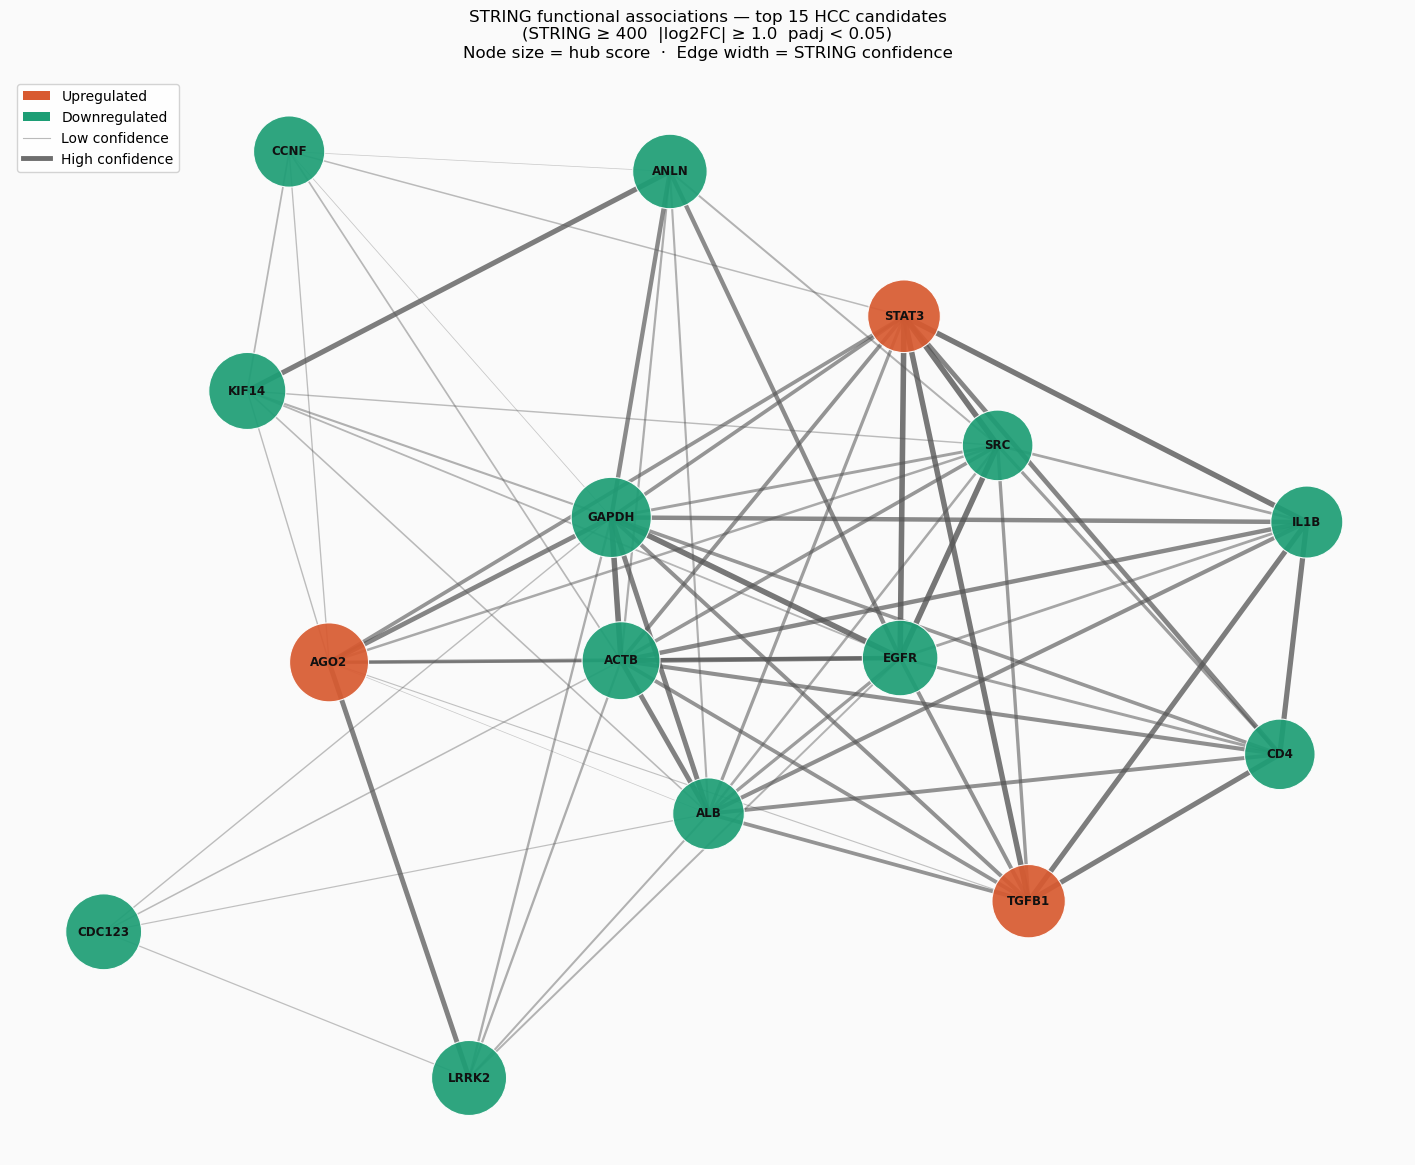

In [7]:
fig, _ = plot_utils.plot_ppi_network(G, hub_df, top_nodes=TOP_VIZ_NODES,
    string_score=STRING_SCORE, log2fc_thresh=LOG2FC_THRESH, padj_thresh=PADJ_THRESH)
fig.savefig(TARGET_FIGURES / "ppi_network.png", dpi=200, bbox_inches="tight")
plt.show()


In [8]:
ppi.export_ppi(hub_df, G, edges_df, TARGET_TABLES)
provenance["ppi_status"] = "completed"
save_provenance()


Saved: hub_genes.csv            (7121 genes)
Saved: ppi_edges_cytoscape.csv  (167480 edges)

Top 5 hub genes: ['GAPDH', 'AGO2', 'ACTB', 'KIF14', 'CDC123']


---
## P2 · Optional survival supporting evidence
Real bulk-tumour TCGA evidence only. Download or validation failure leaves this section unavailable and does not create simulated data. Cox uses continuous expression; KM is descriptive. FDR is within this contrast. A PH flag requires follow-up; a passed screen does not prove proportional hazards. Survival associations do not prove therapeutic benefit.


In [13]:
hub_score_map = hub_df.set_index("gene").hub_score.to_dict()
merged, is_sim = None, False
survival_status = "disabled"


In [14]:
if RUN_SURVIVAL:
    if SURVIVAL_CSV is not None:
        merged = pd.read_csv(SURVIVAL_CSV)
        survival_status = "local_real_data_pending_validation"
        provenance["survival_input"] = str(SURVIVAL_CSV)
        provenance["survival_sha256"] = hashlib.sha256(Path(SURVIVAL_CSV).read_bytes()).hexdigest()
    else:
        merged, is_sim = survival.fetch_tcga_lihc()
        survival_status = "downloaded" if merged is not None else "unavailable"
print("Survival status:", survival_status)


Survival evidence unavailable: 403 Client Error: Forbidden for url: https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.LIHC.sampleMap%2FHiSeqV2
Survival status: unavailable


In [26]:
# Typed empty tables keep reporting and exports safe when survival is unavailable.
surv_raw = pd.DataFrame(columns=["gene", "logrank_p", "cox_p", "cox_p_adj", "logrank_p_adj",
    "HR", "HR_CI_low", "HR_CI_high", "ph_p", "ph_min_p", "ph_warning", "status", "reason", "model", "n_events"])
surv_df, surv_filtered = surv_raw.copy(), surv_raw.copy()
if merged is not None:
    try:
        surv_raw = survival.run_survival(gene_list, merged, covariates=SURVIVAL_COVARIATES)
        surv_df, surv_filtered = survival.filter_survivors(surv_raw, sig, cox_p=COX_FDR_THRESH)
        survival_status = "completed" if surv_raw.status.eq("completed").any() else "no_testable_models"
    except Exception as exc:
        survival_status = "failed_validation_or_analysis"
        provenance["survival_error"] = str(exc)
        print("Survival evidence unavailable:", exc)
display(surv_filtered.head(10))


,gene,logrank_p,cox_p,cox_p_adj,logrank_p_adj,HR,HR_CI_low,HR_CI_high,ph_p,ph_min_p,ph_warning,status,reason,model,n_events


In [27]:
top_genes = surv_filtered.head(TOP_KM).gene.tolist()
if top_genes:
    fig = plot_utils.plot_km_grid(top_genes, surv_df, merged, is_simulated=False)
    fig.savefig(TARGET_FIGURES / "km_plots.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No FDR-supported genes for KM panels; no nonsignificant genes substituted")


No FDR-supported genes for KM panels; no nonsignificant genes substituted


In [28]:
if not surv_filtered.empty:
    fig, _ = plot_utils.plot_cox_forest(surv_filtered, top_n=20, cox_p_thresh=COX_FDR_THRESH)
    fig.savefig(TARGET_FIGURES / "cox_forest_plot.png", dpi=200, bbox_inches="tight")
    plt.show()


In [ ]:
survival.export_survival(surv_df, surv_filtered, TARGET_TABLES)
provenance["survival_status"] = survival_status
save_provenance()


---
## P3 · Drug–gene evidence
Query all shortlisted genes, including network isolates. Survival is supporting annotation, not a gate. Review original citations, directness and drug action before selecting candidates. Drug approval is not HCC approval. Missing metadata stays missing in the evidence table; GNN numeric encoding has missingness flags.

Identity review: database IDs stay distinct unless an explicit confirmed mapping is supplied. Identical normalized names indicate possible aliases, not established chemical equivalence. Notebook 03 keeps those candidate gene–drug alias groups in one label split.

The original max-normalized score remains the baseline. Compare it with log1p/max normalization using the same weights; inspect actual component contributions rather than assuming nominal weights determine influence. Do not choose weights/scaling to promote a desired drug. Within-contrast scores are not calibrated across cell types.

Use `biological_review_queue.csv` after rerunning: assess original mechanism, direction, indication and cell-type support. Downregulated pooled genes are not automatically targets to inhibit. Repeat the contrast for eligible cell types (T cells, B cells, fibroblasts), keeping small/imbalanced and subtype-composition limitations explicit.


In [22]:
print("Database selection:")
for name, flag in [("DGIdb", USE_DGIDB), ("ChEMBL", USE_CHEMBL),
                   ("OpenTargets", USE_OPENTARGETS), ("Curated", USE_CURATED)]:
    print(f"  {name:<14}: {'✓ enabled' if flag else '✗ disabled'}")

Database selection:
  DGIdb         : ✓ enabled
  ChEMBL        : ✗ disabled
  OpenTargets   : ✗ disabled
  Curated       : ✗ disabled


In [23]:
gene_list, hub_score_map = dgi.load_dgi_inputs(TARGET_TABLES)


Candidates for drug queries: 7121


In [24]:
raw_cache = TARGET_TABLES / "dgi_raw_records.json"
status_cache = TARGET_TABLES / "dgi_source_status.json"
reuse_dgidb = (REUSE_SAVED_DGIDB and USE_DGIDB and not USE_CHEMBL and not USE_OPENTARGETS
    and not USE_CURATED and prior_manifest.get("status") == "completed"
    and prior_manifest.get("de_sha256") == provenance["de_sha256"]
    and prior_manifest.get("drug_sources", {}).get("DGIdb", {}).get("status") == "completed"
    and raw_cache.exists() and status_cache.exists()
    and cached_candidate_genes == set(gene_list)
    and (not prior_manifest.get("dgi_raw_sha256") or
         hashlib.sha256(raw_cache.read_bytes()).hexdigest() == prior_manifest["dgi_raw_sha256"]))
if reuse_dgidb:
    all_edges = json.loads(raw_cache.read_text())
    source_status = json.loads(status_cache.read_text())
    if source_status.get("DGIdb", {}).get("status") != "completed":
        raise ValueError("Cached DGIdb snapshot is incomplete")
    apis_ok = ["DGIdb"]
    provenance["dgidb_snapshot_reused_from"] = prior_manifest.get("dgidb_snapshot_reused_from", prior_manifest.get("finished_utc"))
    print("Reusing the completed DGIdb evidence snapshot for this DE input.")
else:
    all_edges, apis_ok, source_status = dgi.collect_interactions(gene_list,
        use_dgidb=USE_DGIDB, use_chembl=USE_CHEMBL, use_opentargets=USE_OPENTARGETS,
        use_curated=USE_CURATED, return_status=True)
    raw_cache.write_text(json.dumps(all_edges, indent=2, default=str))
    status_cache.write_text(json.dumps(source_status, indent=2))
provenance["drug_sources"] = source_status
provenance["dgi_raw_sha256"] = hashlib.sha256(raw_cache.read_bytes()).hexdigest()
save_provenance()


    DGIdb: 27452 interactions returned


In [29]:
dgi_df = dgi.build_dgi_dataframe(all_edges, hub_score_map, W, identity_map, INTERACTION_SCALING)
annotations = hub_df[[c for c in ["gene", "contrast", "cell_type", "group", "reference",
    "log2FC", "adj_pvalue", "regulation", "ppi_connected"] if c in hub_df]]
dgi_df = dgi_df.merge(annotations, on="gene", how="left", validate="many_to_one")
dgi_df["survival_status"] = survival_status
if not surv_df.empty:
    survival_columns = ["gene", "cox_p_adj", "HR", "ph_warning", "model"]
    dgi_df = dgi_df.merge(surv_df[survival_columns], on="gene", how="left", validate="many_to_one")
dgi_df["survival_supported"] = dgi_df.gene.isin(surv_filtered.gene)
dgi_df.to_csv(TARGET_TABLES / "dgi_evidence.csv", index=False)
sensitivity = dgi.score_weight_sensitivity(all_edges, hub_score_map, W, identity_map=identity_map, interaction_scaling=INTERACTION_SCALING)
sensitivity.to_csv(TARGET_TABLES / "score_weight_sensitivity.csv", index=False)
display(dgi_df.head(10))

_, drug_identity_audit = alias_groups(dgi_df)
drug_identity_audit.to_csv(TARGET_TABLES / "drug_identity_audit.csv", index=False)
pd.DataFrame(columns=["drug_id", "canonical_drug_id", "confirmed", "evidence_reference"]).to_csv(
    TARGET_TABLES / "drug_identity_map_template.csv", index=False)
scaling_sensitivity, score_contributions = dgi.score_scaling_sensitivity(all_edges, hub_score_map, W, identity_map)
scaling_sensitivity.to_csv(TARGET_TABLES / "score_scaling_sensitivity.csv", index=False)
score_contributions.to_csv(TARGET_TABLES / "score_component_contributions.csv", index=False)
display(score_contributions)
review_queue = dgi_df.head(100).copy()
review_queue.insert(0, "evidence_rank", range(1, len(review_queue)+1))
for field in ["direct_target_evidence", "desired_action", "hcc_evidence_reference", "celltype_support", "review_decision", "review_notes"]:
    review_queue[field] = ""
review_queue["biological_review_status"] = "pending; pooled DE and database associations are insufficient"
review_queue.to_csv(TARGET_TABLES / "biological_review_queue.csv", index=False)


,gene,drug,drug_id,source,interaction_type,directionality,approved,immunotherapy,anti_neoplastic,publication_ids,...,contrast,cell_type,group,reference,log2FC,adj_pvalue,regulation,ppi_connected,survival_status,survival_supported
0,TPP1,CERLIPONASE ALFA,rxcui:1922436,DGIdb,unknown,unknown,True,False,False,,...,pooled,All cells,tumor (HCC2),normal (HCC1),-2.669992,0.000000e+00,down,True,unavailable,False
1,SLC40A1,LY2928057,iuphar.ligand:8416,DGIdb,antibody,INHIBITORY,False,False,False,22290531,...,pooled,All cells,tumor (HCC2),normal (HCC1),-3.979765,0.000000e+00,down,True,unavailable,False
2,IFNGR2,INTERFERON GAMMA-1B,rxcui:5882,DGIdb,agonist,ACTIVATING,True,True,False,,...,pooled,All cells,tumor (HCC2),normal (HCC1),-2.580205,0.000000e+00,down,True,unavailable,False
3,HPD,NITISINONE,rxcui:61805,DGIdb,inhibitor,INHIBITORY,True,False,False,,...,pooled,All cells,tumor (HCC2),normal (HCC1),-7.476993,2.366006e-62,down,True,unavailable,False
4,NEU3,OSELTAMIVIR PHOSPHATE,rxcui:259275,DGIdb,unknown,unknown,True,False,False,18694948,...,pooled,All cells,tumor (HCC2),normal (HCC1),-1.304986,1.657500e-45,down,True,unavailable,False
5,TCN1,COBALAMIN,ncit:C939,DGIdb,unknown,unknown,False,False,False,10207776 | 1176445 | 1285639 | 1504859 | 22359...,...,pooled,All cells,tumor (HCC2),normal (HCC1),5.230205,7.119465e-50,up,True,unavailable,False
6,RPA1,CHEMBL:CHEMBL1765371,chembl:CHEMBL1765371,DGIdb,unknown,unknown,False,False,False,21459001,...,pooled,All cells,tumor (HCC2),normal (HCC1),-1.162709,7.500964e-103,down,True,unavailable,False
7,PROM1,ICT-121 DENDRITIC CELL VACCINE,ncit:C124652,DGIdb,unknown,unknown,False,False,False,25691822,...,pooled,All cells,tumor (HCC2),normal (HCC1),7.378534,1.506188e-52,up,True,unavailable,False
8,UQCR10,FAMOXADONE,chembl:CHEMBL10118,DGIdb,unknown,unknown,False,False,False,10843216,...,pooled,All cells,tumor (HCC2),normal (HCC1),-2.133161,0.000000e+00,down,True,unavailable,False
9,ELN,VONAPANITASE,chembl:CHEMBL3545070,DGIdb,cleavage,INHIBITORY,False,False,False,,...,pooled,All cells,tumor (HCC2),normal (HCC1),2.305416,1.103083e-02,up,True,unavailable,False


,interaction_scaling,component,nominal_weight,median_contribution,p90_contribution
0,max,interaction,0.65,0.000659,0.010833
1,max,publications,0.00,0.000000,0.000000
2,max,phase,0.00,0.000000,0.000000
3,max,approved,0.15,0.000000,0.150000
4,max,hub,0.20,0.053651,0.088678
5,log1p_max,interaction,0.65,0.019112,0.165744
6,log1p_max,publications,0.00,0.000000,0.000000
7,log1p_max,phase,0.00,0.000000,0.000000
8,log1p_max,approved,0.15,0.000000,0.150000
9,log1p_max,hub,0.20,0.053651,0.088678


Saved (combined): C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures\target_prioritisation\pooled\dgi_summary_dashboard.png
Saved (panel)  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures\target_prioritisation\pooled\dgi_panel_A_interactions.png
Saved (panel)  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures\target_prioritisation\pooled\dgi_panel_B_interaction_types.png
Saved (panel)  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures\target_prioritisation\pooled\dgi_panel_C_approval.png
Saved (panel)  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures\target_prioritisation\pooled\dgi_panel_D_clinical_phase.png
Saved (panel)  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures\target_prioritisation\pooled\dgi_panel_E_score_heatmap.png


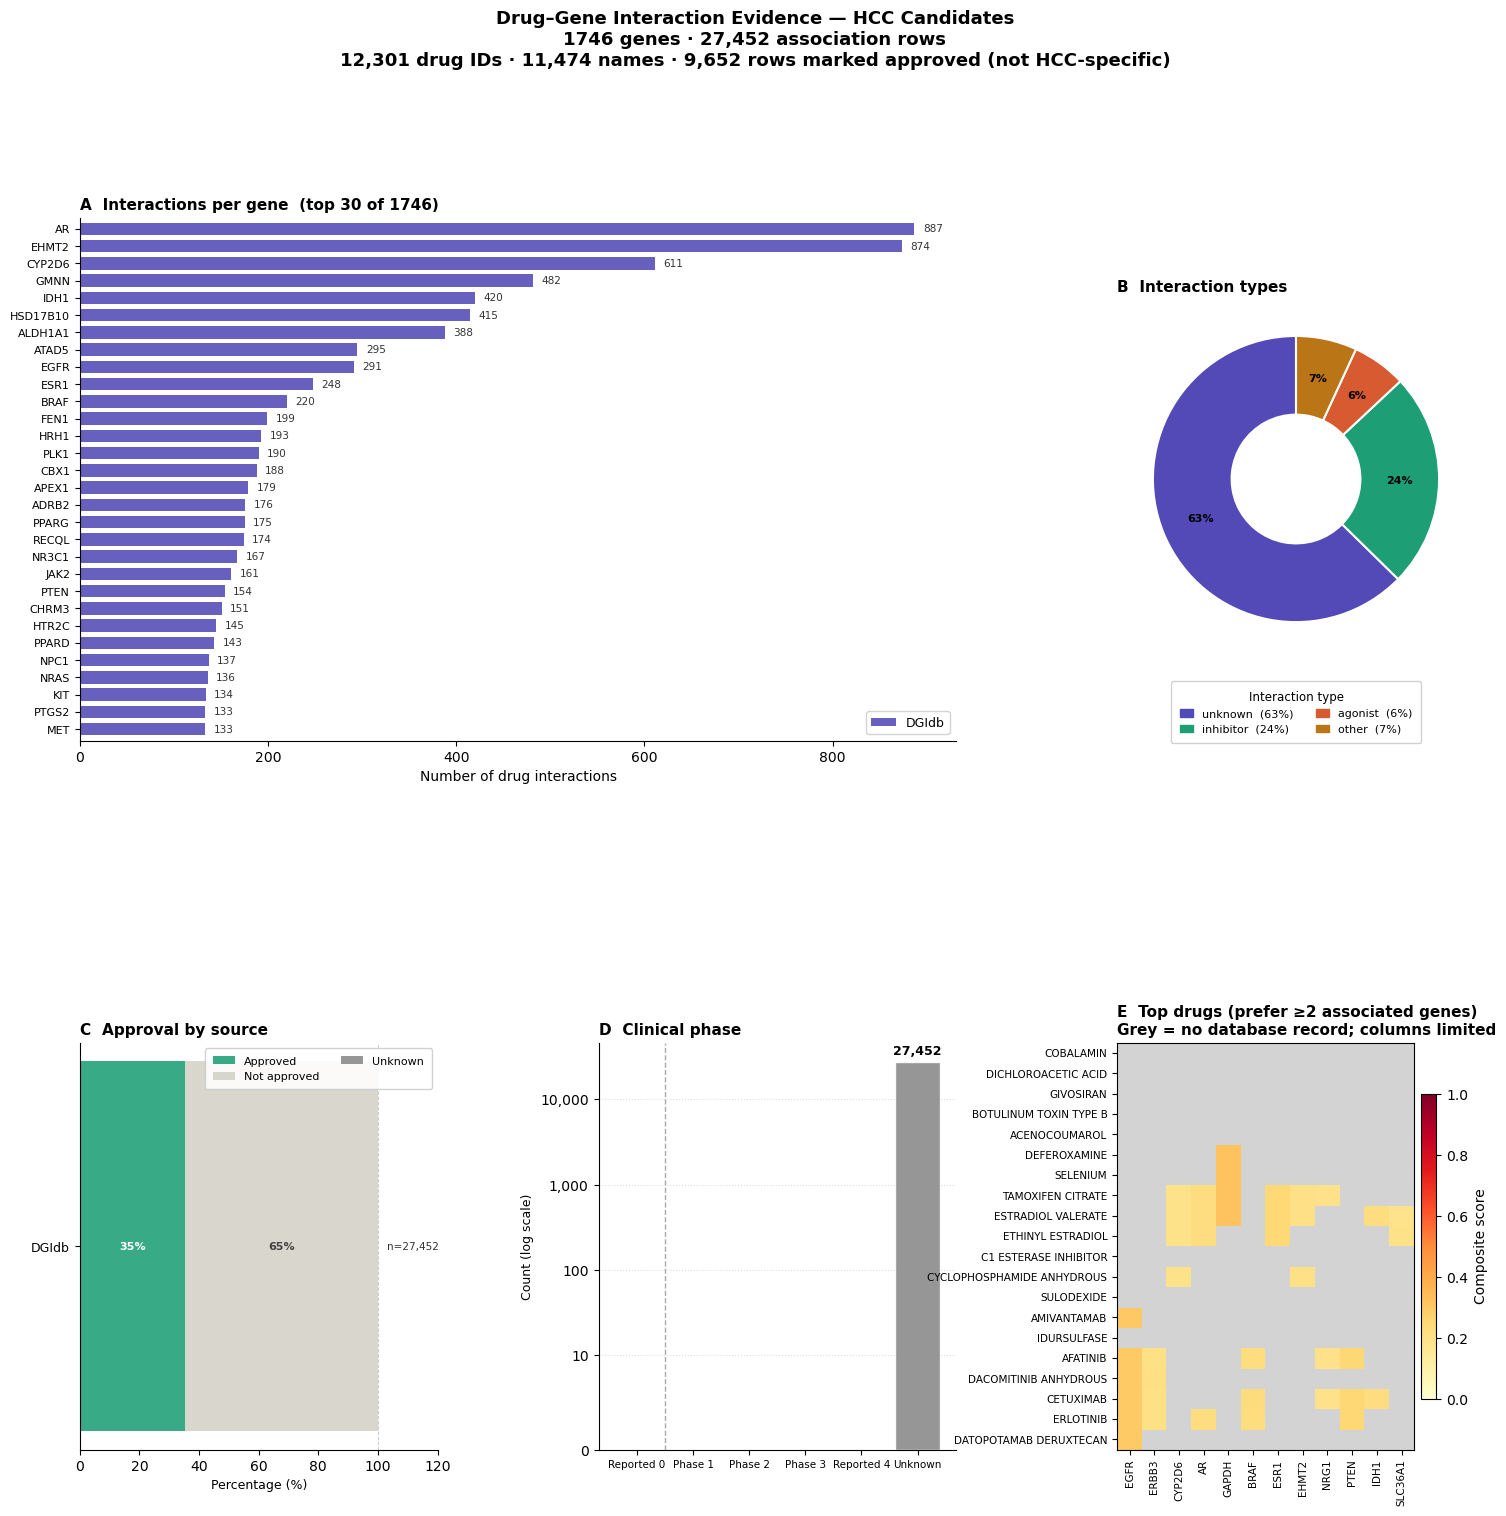

In [30]:
if not dgi_df.empty:
    dgi.plot_dgi_dashboard(dgi_df, TARGET_FIGURES)
else:
    print("No drug evidence available. Inspect dgi_source_status.json before proceeding.")


In [31]:
gnn_df = dgi.build_gnn_edge_list(dgi_df, hub_score_map, TARGET_TABLES)
GNN_INPUT = TARGET_TABLES / "dgi_edges_gnn.csv"
print("Notebook 03 input:", GNN_INPUT)
if gnn_df.empty:
    print("STOP: no interactions for GNN analysis")
provenance["dgi_edges_sha256"] = hashlib.sha256(GNN_INPUT.read_bytes()).hexdigest()
provenance["survival_status"] = survival_status
provenance["status"] = "ready_for_report"
provenance["finished_utc"] = datetime.now(timezone.utc).isoformat()
save_provenance()


Notebook 03 input: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\tables\target_prioritisation\pooled\dgi_edges_gnn.csv


---
## Report
Per-contrast evidence summary, including unavailable sources and analysis limitations.


In [32]:
provenance["status"] = "completed" if not gnn_df.empty else "completed_without_drug_edges"
try:
    report_path = report_functions.generate_target_report(
        sig=sig, gene_list=gene_list, G=G, hub_df=hub_df, edges_df=edges_df,
        string_score=STRING_SCORE, log2fc_thresh=LOG2FC_THRESH, padj_thresh=PADJ_THRESH,
        surv_df=surv_df, surv_filtered=surv_filtered, is_sim=False,
        km_p_thresh=0.05, cox_p_thresh=COX_FDR_THRESH, hr_min=0.8, hr_max=1.2,
        dgi_df=dgi_df, apis_ok=apis_ok, use_dgidb=USE_DGIDB,
        use_chembl=USE_CHEMBL, use_opentargets=USE_OPENTARGETS, use_curated=USE_CURATED, W=W,
        figures_dir=TARGET_FIGURES, tables_dir=TARGET_TABLES, reports_dir=TARGET_REPORTS,
        contrast=CONTRAST, survival_status=survival_status, source_status=source_status, provenance=provenance)
    print("Report:", report_path)
except Exception as exc:
    provenance.update(status="failed_report", report_error=str(exc))
    raise
finally:
    save_provenance()


  Report saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\reports\target_prioritisation\pooled\02_target_prioritisation_report.html
Report: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\reports\target_prioritisation\pooled\02_target_prioritisation_report.html
